Keypoints in img1: 1500
Keypoints in img2: 288
Descriptor shape img1: (1500, 32)
Descriptor shape img2: (288, 32)


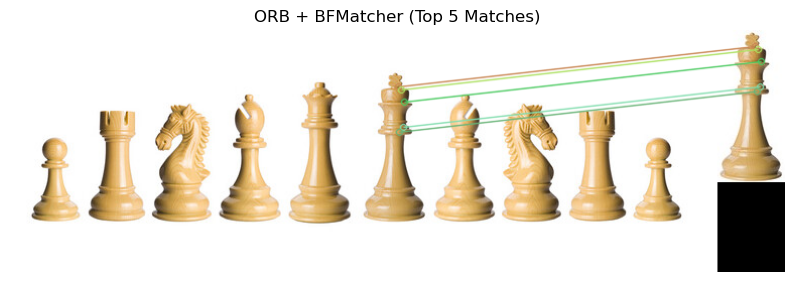

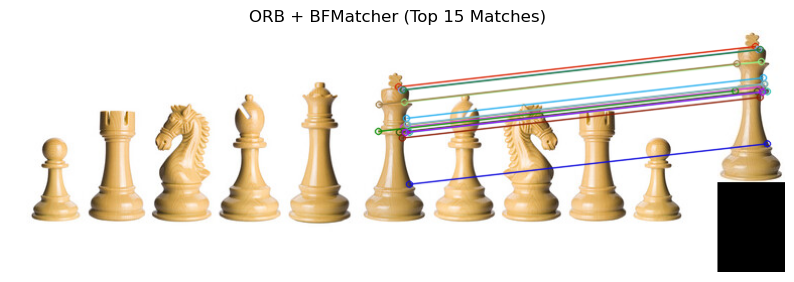

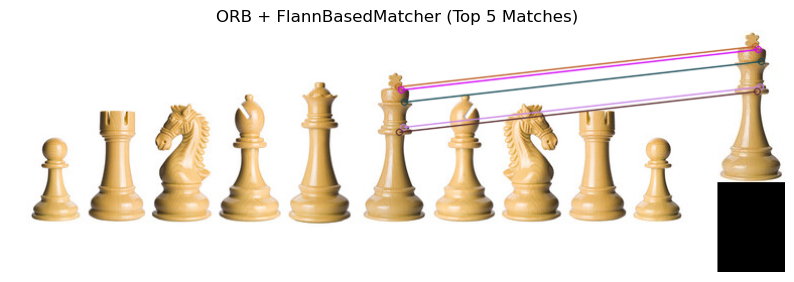

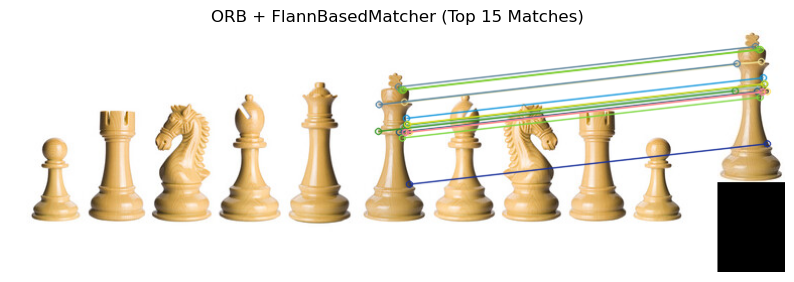

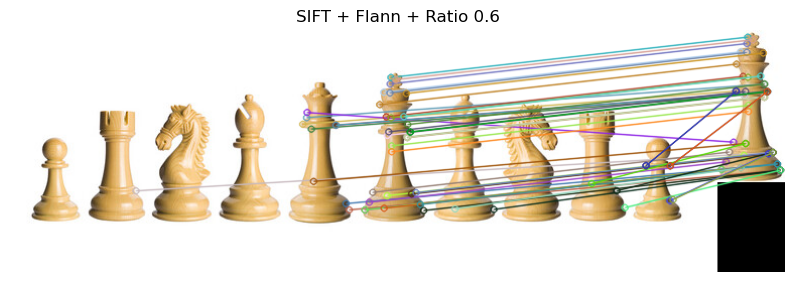

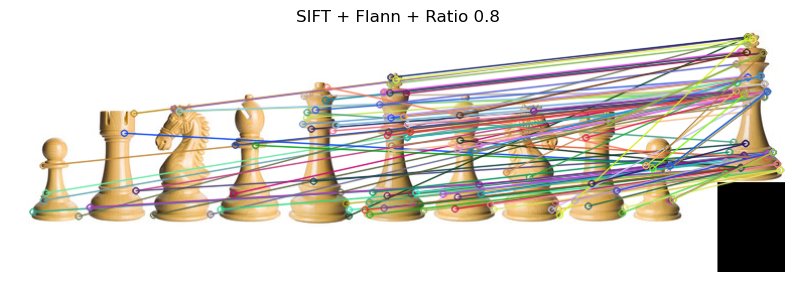

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_matches(img1, kp1, img2, kp2, matches, title):
    matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# 1. Load images
img1 = cv2.imread('images/Chess_Pieces.jpg')
img2 = cv2.imread('images/King.jpg')

# 2. ORB descriptors
orb = cv2.ORB_create(nfeatures=1500, scaleFactor=1.2, edgeThreshold=5) #orb sensitivity increased
kp1_orb, des1_orb = orb.detectAndCompute(img1, None)
kp2_orb, des2_orb = orb.detectAndCompute(img2, None)

print(f"Keypoints in img1: {len(kp1_orb)}")
print(f"Keypoints in img2: {len(kp2_orb)}")
print(f"Descriptor shape img1: {des1_orb.shape if des1_orb is not None else 'None'}")
print(f"Descriptor shape img2: {des2_orb.shape if des2_orb is not None else 'None'}")

# BFMatcher with ORB
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

if des1_orb is not None and des2_orb is not None:
    des1_orb = np.asarray(des1_orb, dtype=np.uint8)
    des2_orb = np.asarray(des2_orb, dtype=np.uint8)

    matches_bf_orb = bf_orb.match(des1_orb, des2_orb)
    matches_bf_orb = sorted(matches_bf_orb, key=lambda x: x.distance)

    show_matches(img1, kp1_orb, img2, kp2_orb, matches_bf_orb[:5], 'ORB + BFMatcher (Top 5 Matches)')
    show_matches(img1, kp1_orb, img2, kp2_orb, matches_bf_orb[:15], 'ORB + BFMatcher (Top 15 Matches)')
else:
    print("Descriptor extraction failed for one or both images.")

# FLANN with ORB (requires conversion to float32)
# FLANN parameters for ORB (binary descriptors)
index_params = dict(algorithm=6,  # FLANN_INDEX_LSH
                    table_number=6,
                    key_size=12,
                    multi_probe_level=1)
search_params = dict(checks=50)

flann_orb = cv2.FlannBasedMatcher(index_params, search_params)

if des1_orb is not None and des2_orb is not None:
    des1_orb = np.asarray(des1_orb, dtype=np.uint8)
    des2_orb = np.asarray(des2_orb, dtype=np.uint8)

    matches_flann_orb = flann_orb.match(des1_orb, des2_orb)
    matches_flann_orb = sorted(matches_flann_orb, key=lambda x: x.distance)

    show_matches(img1, kp1_orb, img2, kp2_orb, matches_flann_orb[:5], 'ORB + FlannBasedMatcher (Top 5 Matches)')
    show_matches(img1, kp1_orb, img2, kp2_orb, matches_flann_orb[:15], 'ORB + FlannBasedMatcher (Top 15 Matches)')
else:
    print("Descriptor extraction failed for one or both images.")

# 3. Explanation
#Keypoints are matched by comparing descriptors using a distance metric.
#BFMatcher uses brute-force to compare every descriptor pair.
#FlannBasedMatcher uses approximate nearest neighbors for faster matching.
#Thus, FlannBasedMatcher is generally faster and better for large datasets, but BFMatcher may be more accurate for small sets like ORB.

# 4. SIFT descriptors + Flann + Ratio Matching
sift = cv2.SIFT_create()
kp1_sift, des1_sift = sift.detectAndCompute(img1, None)
kp2_sift, des2_sift = sift.detectAndCompute(img2, None)

index_params_sift = dict(algorithm=1, trees=5)
search_params_sift = dict(checks=50)
flann_sift = cv2.FlannBasedMatcher(index_params_sift, search_params_sift)

matches_sift = flann_sift.knnMatch(des1_sift, des2_sift, k=2)

# Ratio Matching
def ratio_match(matches, ratio):
    good = []
    for m, n in matches:
        if m.distance < ratio * n.distance:
            good.append(m)
    return good

for ratio in [0.6, 0.8]:
    good_matches = ratio_match(matches_sift, ratio)
    show_matches(img1, kp1_sift, img2, kp2_sift, good_matches, f'SIFT + Flann + Ratio {ratio}')

# 5. Explanation of ratio
#The distance ratio filters out ambiguous matches:
# Lower ratios (e.g., 0.6) are stricter, keeping only strong matches.
# Higher ratios (e.g., 0.8) allow more matches, including weaker ones.
#This affects both the quantity and quality of matches.